In [51]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color
from skimage.segmentation import chan_vese
from skimage.measure import label, regionprops

from sklearn.ensemble import RandomForestRegressor

In [ ]:
# ----------------------------
# 1. SEGMENTATION (Chan-Vese)
# ----------------------------
def segment_image(image):

    if len(image.shape) == 3:
        image = color.rgb2gray(image)

    cv = chan_vese(
        image,
        mu=0.25,
        lambda1=1,
        lambda2=1,
        tol=1e-3,
        max_num_iter=200,
        dt=0.5,
        init_level_set="checkerboard",
        extended_output=False,
    )

    return cv.astype(int)

In [53]:
# ----------------------------
# 2. FEATURE EXTRACTION
# ----------------------------
def extract_features(mask):

    # Porosity (assuming pores = 0)
    porosity = np.mean(mask == 0)

    # Label particles (assuming particles = 1)
    labeled = label(mask == 1)

    regions = regionprops(labeled)

    if len(regions) == 0:
        return np.array([porosity, 0, 0])

    sizes = [r.area for r in regions]

    mean_size = np.mean(sizes)
    std_size = np.std(sizes)

    return np.array([porosity, mean_size, std_size])


In [54]:
# ----------------------------
# 3. FAKE DATA (FOR TESTING)
# ----------------------------
# Replace this later with real SEM + real electrochemistry
def generate_fake_data(n_samples=20):

    X = []
    y = []

    for i in range(n_samples):

        # fake image
        img = np.random.rand(128, 128)

        mask = segment_image(img)
        features = extract_features(mask)

        # fake relationship (for testing pipeline)
        target = (
            0.5 * features[0] +
            0.0001 * features[1] +
            0.2 * features[2] +
            np.random.randn() * 0.01
        )

        X.append(features)
        y.append(target)

    return np.array(X), np.array(y)


In [55]:
def real_data():

    X = []
    y = []


    # fake image
    img_1 = io.imread("sem_data/LFP_backscatter_fresh_001.tif")
    img_2 = io.imread("sem_data/LFP_backscatter_fresh_004.tif")

    mask_1 = segment_image(img_1)
    mask_2 = segment_image(img_2)

    features_1 = extract_features(mask_1)
    features_2 = extract_features(mask_2)

    # fake relationship (for testing pipeline)
    target_1 = (168)
    target_2 = (170)

    X.append(features_1)
    X.append(features_2)
    y.append(target_1)
    y.append(target_2)

    return np.array(X), np.array(y)

In [56]:
# ----------------------------
# 4. TRAIN FORWARD MODEL
# ----------------------------
X, y = generate_fake_data(50)

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

RandomForestRegressor()

In [57]:
# ----------------------------
# 4. TRAIN FORWARD MODEL
# ----------------------------
X, y = real_data()

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

RandomForestRegressor()

In [58]:
# ----------------------------
# 5. TEST ON NEW IMAGE
# ----------------------------
test_img = io.imread("sem_data/LFP_backscatter_fresh_005.tif")

mask = segment_image(test_img)
features = extract_features(mask)

prediction = model.predict([features])

print("Features:", features)
print("Predicted electrochemical value:", prediction[0])

Features: [4.13523402e-01 2.27848927e+03 9.45800541e+03]
Predicted electrochemical value: 169.62


In [60]:
# ----------------------------
# 5. TEST ON NEW IMAGE
# ----------------------------
test_img = io.imread("sem_data/Moha_LFP_S1C_40000mag_BSED_002.tif")

mask = segment_image(test_img)
features = extract_features(mask)

prediction = model.predict([features])

print("Features:", features)
print("Predicted electrochemical value:", prediction[0])

Features: [5.34220076e-01 5.11104545e+03 4.11657037e+04]
Predicted electrochemical value: 169.36


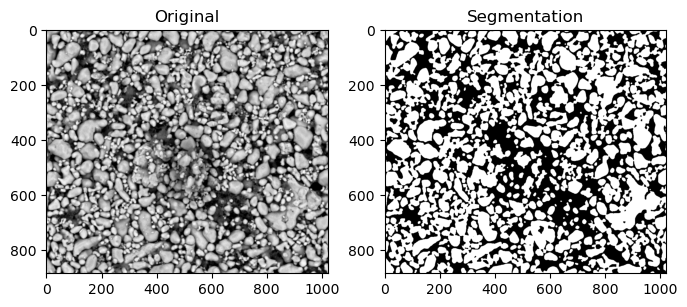

In [59]:
# ----------------------------
# 6. VISUALIZE
# ----------------------------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(test_img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Segmentation")
plt.imshow(mask, cmap='gray')

plt.show()